# Prédiction des précipitations

Notre souhait est d'ajouter la prédiction des précipitations à notre planificateur automatique, en plus de la température. Cela permettrait d'apporter des éléments concrets aux agriculteurs pour mieux les guider : l'idée est de les aider à anticiper de fortes pluies qui pourraient abîmer les plantations, ou au contraire, de prévoir les moments où le sol est trop sec pour adapter l'arrosage.

## Sarima

L'idée de base c'était de réutiliser les codes utilisés pour prédire la temperature, mais on c'est rendu compte qu'on devrait faire quelques ajustements qui sont: 
- Le mode de calcul : Pour la température, on calculait une moyenne hebdomadaire. Pour la pluie, on calcule la somme cumulée (le total tombé dans la semaine).

- La gestion du "vide" : Si une donnée de température manquait, on devinait la valeur entre deux points (interpolation). Pour la pluie, on remplace les manques par 0, car on ne peut pas inventer une averse qui n'est pas enregistrée.

⏳ Chargement de l'historique d'entraînement...
✅ Fichier de test synop_2026.csv chargé pour la validation.
📊 Fin de l'entraînement : 2026-01-04 00:00:00+00:00
🔮 Début de la prédiction : 1ère semaine de Janvier 2026

🚀 Calcul du modèle SARIMA (cela peut prendre quelques secondes)...


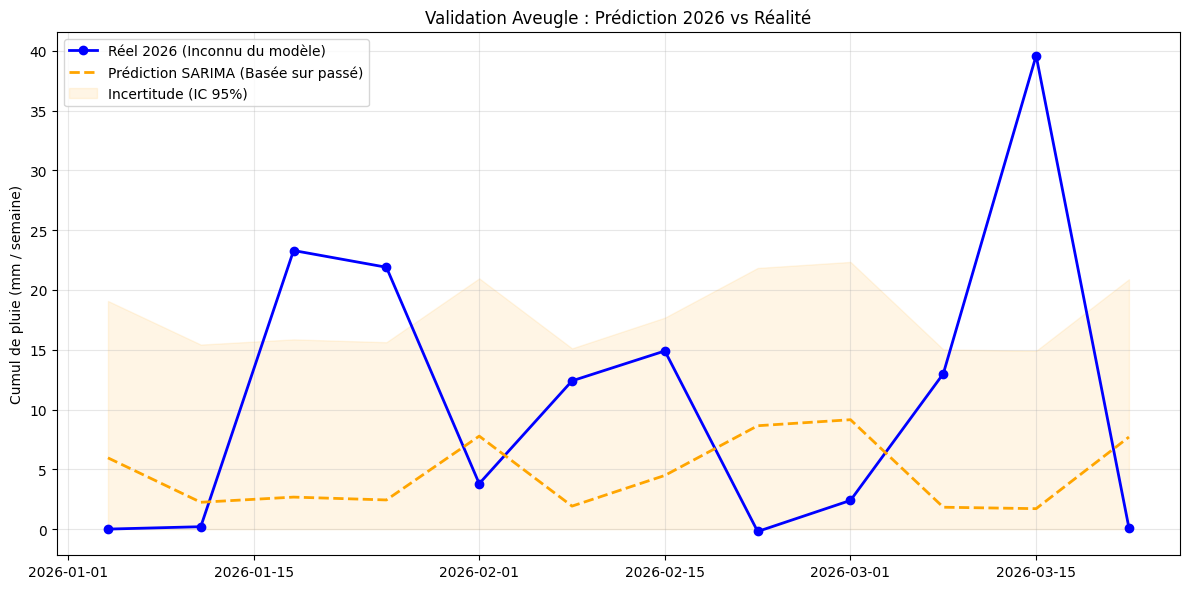


✅ PERFORMANCES RÉELLES SUR 2026 :
📏 MAE  : 12.10 mm
📏 RMSE : 15.33 mm

💾 Fichier 'comparaison_sarima_2026.csv' sauvegardé.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# =========================================================
# 1) CHARGEMENT SÉLECTIF (DÉCOUPAGE PHYSIQUE)
# =========================================================
print("⏳ Chargement de l'historique d'entraînement...")
all_files = sorted(glob.glob("synop_*.csv"))

# On sépare les fichiers : on exclut 2026 de l'entraînement
train_files = [f for f in all_files if "2026" not in f]
file_2026 = "synop_2026.csv"

if not train_files:
    raise FileNotFoundError("Aucun fichier d'historique (avant 2026) trouvé !")

cols = ['validity_time', 'rr1', 'name']

# Chargement DATA ENTRAÎNEMENT (Train)
df_raw_train = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=cols) for f in train_files])

# Chargement DATA TEST 2026 (Vérité terrain)
try:
    df_2026_raw = pd.read_csv(file_2026, sep=";") 
    print(f"✅ Fichier de test {file_2026} chargé pour la validation.")
except FileNotFoundError:
    print(f"⚠️ {file_2026} absent du dossier. On prédira 2026 sans comparaison réelle.")
    df_2026_raw = pd.DataFrame()

# =========================================================
# 2) PRÉPARATION ET NETTOYAGE
# =========================================================
def clean_meteo_df(data):
    if data.empty: return data
    # Filtrage station Montpellier
    data = data[data['name'] == "MONTPELLIER-AEROPORT"].copy()
    data["date"] = pd.to_datetime(data["validity_time"], utc=True)
    data["rr1"] = pd.to_numeric(data["rr1"], errors="coerce").fillna(0)
    return data.sort_values("date")

df_train = clean_meteo_df(df_raw_train)
df_2026 = clean_meteo_df(df_2026_raw)

# =========================================================
# 3) AGRÉGATION HEBDOMADAIRE (Somme cumulée)
# =========================================================
# Série d'entraînement (S'arrête au 31/12/2025)
weekly_train = df_train.groupby(pd.Grouper(key="date", freq="W"))["rr1"].sum()
weekly_train = weekly_train.asfreq("W").fillna(0)

# Série de test (Uniquement 2026)
if not df_2026.empty:
    weekly_2026_real = df_2026.groupby(pd.Grouper(key="date", freq="W"))["rr1"].sum()
    weekly_2026_real = weekly_2026_real.asfreq("W").fillna(0)
else:
    # Si pas de fichier 2026, on crée un index vide pour l'export
    weekly_2026_real = pd.Series(dtype=float)

print(f"📊 Fin de l'entraînement : {weekly_train.index.max()}")
print(f"🔮 Début de la prédiction : 1ère semaine de Janvier 2026")

# =========================================================
# 4) ENTRAÎNEMENT DU MODÈLE (Sur l'historique uniquement)
# =========================================================
# Paramètres : (p,d,q) x (P,D,Q,s)
# s=52 car on travaille sur des cycles hebdomadaires annuels
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 52) 

print(f"\n🚀 Calcul du modèle SARIMA (cela peut prendre quelques secondes)...")
model = SARIMAX(weekly_train, 
                order=order, 
                seasonal_order=seasonal_order,
                enforce_stationarity=False, 
                enforce_invertibility=False)

results = model.fit(disp=False)

# =========================================================
# 5) PRÉVISION DE L'ANNÉE 2026 EN AVEUGLE
# =========================================================
# On prévoit le nombre de semaines correspondant à notre fichier 2026
# (ou 52 semaines par défaut)
steps_to_predict = len(weekly_2026_real) if not weekly_2026_real.empty else 52

forecast_obj = results.get_forecast(steps=steps_to_predict)
forecast_2026 = np.maximum(forecast_obj.predicted_mean, 0) # Pas de pluie négative
conf_int = forecast_obj.conf_int()

# Réalignement des dates pour le graphique
forecast_2026.index = weekly_2026_real.index if not weekly_2026_real.empty else pd.date_range(weekly_train.index.max() + pd.Timedelta(weeks=1), periods=steps_to_predict, freq="W")

# =========================================================
# 6) GRAPHIQUE ET ÉVALUATION
# =========================================================
plt.figure(figsize=(12, 6))

# Réel (si disponible)
if not weekly_2026_real.empty:
    plt.plot(weekly_2026_real.index, weekly_2026_real.values, label="Réel 2026 (Inconnu du modèle)", color="blue", lw=2, marker='o')

# Prédiction
plt.plot(forecast_2026.index, forecast_2026.values, label="Prédiction SARIMA (Basée sur passé)", color="orange", linestyle="--", lw=2)

# Intervalle de confiance
plt.fill_between(forecast_2026.index, np.maximum(conf_int.iloc[:, 0], 0), conf_int.iloc[:, 1], color='orange', alpha=0.1, label="Incertitude (IC 95%)")

plt.title("Validation Aveugle : Prédiction 2026 vs Réalité")
plt.ylabel("Cumul de pluie (mm / semaine)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Métriques finales
if not weekly_2026_real.empty:
    rmse = np.sqrt(mean_squared_error(weekly_2026_real, forecast_2026))
    mae = mean_absolute_error(weekly_2026_real, forecast_2026)
    print(f"\n✅ PERFORMANCES RÉELLES SUR 2026 :")
    print(f"📏 MAE  : {mae:.2f} mm")
    print(f"📏 RMSE : {rmse:.2f} mm")
    
    # Export pour vérification externe
    df_export = pd.DataFrame({'Reel': weekly_2026_real, 'Pred': forecast_2026})
    df_export.to_csv("comparaison_sarima_2026.csv")
    print("\n💾 Fichier 'comparaison_sarima_2026.csv' sauvegardé.")

On obtient un RMSE de 15.33 mm, ce qui est une grande erreur.
- Le point faible : Il est "trop prudent". Il prédit une moyenne saisonnière lisse mais rate les pics brutaux (comme celui de 40 mm en mars).
- Le point fort : L'intervalle de confiance (zone beige) englobe bien la réalité, ce qui prouve que le modèle identifie les périodes à risque, même s'il sous-estime leur intensité.
À travers ce premier test on voit qu'on ne peut pas prédire les précipitations aussi facilement que la température, pour laquelle ce modèl avait obtenu un bon résultat. 

## XGBOOST

Nous avons également testé le modèle XGBoost, que nous avions déjà utilisé pour la température.

Le code est découpé en trois parties (modèle, prédiction, comparaison) pour garantir que le modèle ne s'entraîne pas sur les données qu'il doit prédire. 

Ce modèle XGBOOST utilise les "Lags" en regardant la pression et l'humidité des heures précédentes pour détecter l'arrivée d'une averse.

In [ ]:
import pandas as pd
import numpy as np
import glob
import xgboost as xgb
import joblib

# 1. CHARGEMENT DE L'HISTORIQUE (2022-2025)
files = sorted(glob.glob("synop_*.csv"))
train_files = [f for f in files if "2026" not in f]
cols = ['validity_time', 't', 'u', 'pres', 'rr1', 'name']

df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=cols) for f in train_files])
df = df_raw[df_raw['name'] == "HIVA-OA"].copy()
df['ds'] = pd.to_datetime(df['validity_time'], utc=True)
df = df.sort_values('ds').set_index('ds')

# 2. NETTOYAGE ET LAGS
df['rr1'] = pd.to_numeric(df['rr1'], errors='coerce').fillna(0).clip(lower=0)
df['u'] = pd.to_numeric(df['u'],x errors='coerce').interpolate().bfill()
df['pres'] = pd.to_numeric(df['pres'], errors='coerce').interpolate().bfill()
df['t_c'] = pd.to_numeric(df['t'], errors='coerce').interpolate().bfill() - 273.15

for i in [1, 2, 3, 4]:
    df[f'u_lag_{i}'] = df['u'].shift(i)
    df[f'pres_lag_{i}'] = df['pres'].shift(i)
    df[f'rr1_lag_{i}'] = df['rr1'].shift(i)
df['hr_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df = df.dropna()

features = [c for c in df.columns if 'lag' in c or c in ['u', 'pres', 't_c', 'hr_sin']]
X, y = df[features].astype(np.float32), df['rr1'].astype(np.float32)

# 3. FIT
model = xgb.XGBRegressor(n_estimators=500, objective='reg:tweedie')
model.fit(X, y)

# 4. EXPORT DU CERVEAU + DERNIER ÉTAT CONNU (Fin 2025)
joblib.dump(model, "model_xgb_pluie.pkl")
joblib.dump(features, "features_list.pkl")
df.tail(10).to_csv("last_known_state_2025.csv") # Sauvegarde le "présent" pour le Code 2
print("✅ Modèle entraîné. Historique clos au 31/12/2025.")

✅ Modèle entraîné. Historique clos au 31/12/2025.


In [43]:
import pandas as pd
import numpy as np
import joblib

# 1. Chargement
model = joblib.load("model_xgb_pluie.pkl")
features = joblib.load("features_list.pkl")
df_state = pd.read_csv("last_known_state_2025.csv", index_col='ds')
df_state.index = pd.to_datetime(df_state.index)

# 2. Boucle de prédiction (7 jours * 8 points/jour = 56 points)
predictions = []
current_features = df_state[features].tail(1).copy()

print("🔮 Projection en aveugle sur 7 jours...")

for i in range(56): 
    # Prédiction du créneau actuel
    pred_val = model.predict(current_features.astype(np.float32))[0]
    pred_val = max(0, pred_val) # On nettoie le bruit numérique
    
    # Calcul de la date future
    next_date = df_state.index[-1] + pd.Timedelta(hours=3*(i+1))
    predictions.append({'ds': next_date, 'y_pred': pred_val})
    
    # --- MISE À JOUR AUTO-RÉGRESSIVE DES FEATURES ---
    new_row = current_features.iloc[0].copy()
    
    # On décale les lags de pluie (le rr1 prédit devient le nouveau lag_1)
    new_row['rr1_lag_4'] = new_row['rr1_lag_3']
    new_row['rr1_lag_3'] = new_row['rr1_lag_2']
    new_row['rr1_lag_2'] = new_row['rr1_lag_1']
    new_row['rr1_lag_1'] = pred_val 
    
    # Mise à jour temporelle
    new_row['hr_sin'] = np.sin(2 * np.pi * next_date.hour / 24)
    
    # NOTE : On garde 'u', 'pres' et 't_c' constants (persistance) 
    # car on ne connaît pas encore le futur de ces variables.
    
    current_features.iloc[0] = new_row

# 3. Sauvegarde
df_forecast = pd.DataFrame(predictions)
df_forecast.to_csv("semaine_aveugle_2026.csv", index=False)
print("✅ Fichier 'semaine_aveugle_2026.csv' généré.")

🔮 Projection en aveugle sur 7 jours...
✅ Fichier 'semaine_aveugle_2026.csv' généré.


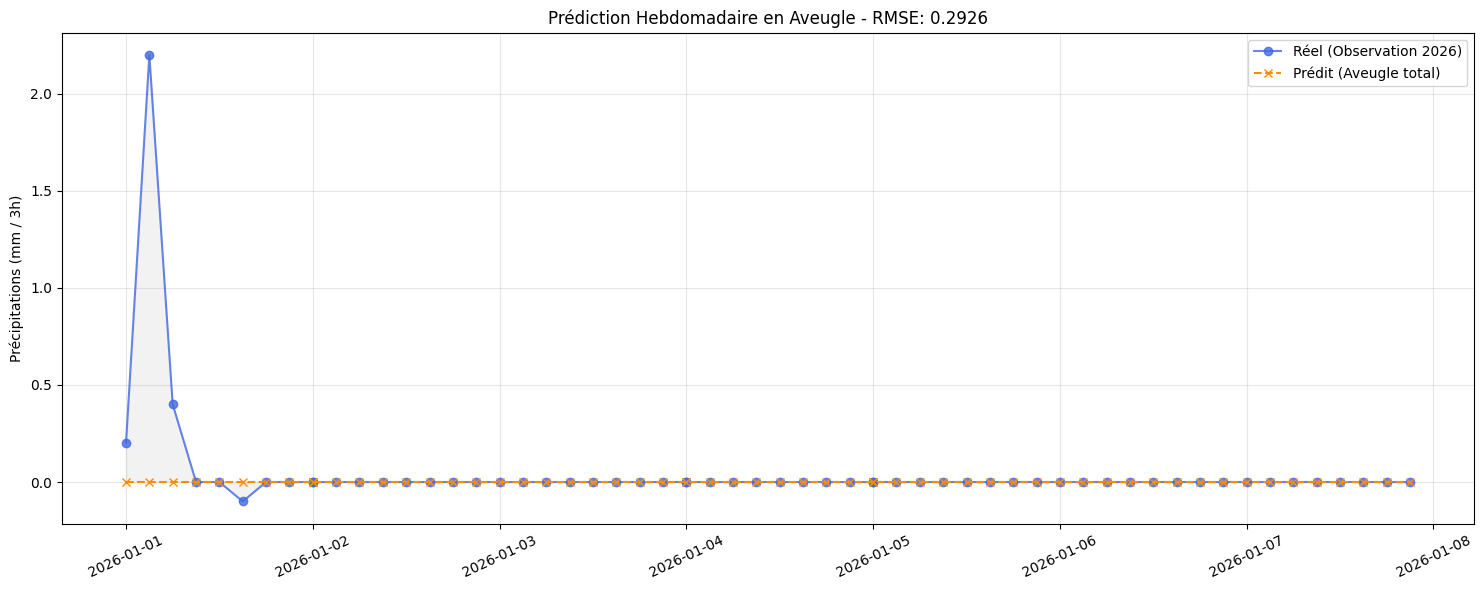

📊 RMSE sur 1 semaine : 0.2926


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Lecture
df_pred = pd.read_csv("semaine_aveugle_2026.csv")
df_2026 = pd.read_csv("synop_2026.csv", sep=";")

# 2. Préparation
df_pred['ds'] = pd.to_datetime(df_pred['ds'], utc=True)
df_2026['ds'] = pd.to_datetime(df_2026['validity_time'], utc=True)
df_2026 = df_2026[df_2026['name'] == "HIVA-OA"]
df_2026['rr1'] = pd.to_numeric(df_2026['rr1'], errors='coerce').fillna(0)

# Fusion pour aligner les dates
df_final = pd.merge(df_pred, df_2026[['ds', 'rr1']], on='ds', how='inner')

# 3. Calcul du RMSE Global sur la semaine
rmse = np.sqrt(mean_squared_error(df_final['rr1'], df_final['y_pred']))

# 4. Graphique
plt.figure(figsize=(15, 6))
plt.plot(df_final['ds'], df_final['rr1'], label="Réel (Observation 2026)", 
         color='royalblue', marker='o', alpha=0.8)
plt.plot(df_final['ds'], df_final['y_pred'], label="Prédit (Aveugle total)", 
         color='darkorange', ls='--', marker='x')

plt.fill_between(df_final['ds'], df_final['rr1'], df_final['y_pred'], color='gray', alpha=0.1)
plt.title(f"Prédiction Hebdomadaire en Aveugle - RMSE: {rmse:.4f}")
plt.ylabel("Précipitations (mm / 3h)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

print(f"📊 RMSE sur 1 semaine : {rmse:.4f}")

En aveugle, le modèle finit par prédire 0 mm car il ne voit pas les nuages arriver. Sans connaître l'évolution de la pression ou de l'humidité, il choisit la sécurité en annonçant du beau temps. Pour que le planificateur soit efficace, il faudrait donc lui donner les vraies météos du jour plutôt que de le laisser deviner toute une semaine seul.

## LSTM

Comme notre meilleur résultat pour la prédiction d'une journée de temperature on a voulu voir comment qu'on arriverait a prédire les précipitations avec un lstm.

In [45]:
import pandas as pd
import numpy as np
import glob
import joblib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

# ==========================================
# 1. CHARGEMENT ET NETTOYAGE MASSIF
# ==========================================
files = sorted(glob.glob("synop_*.csv"))
cols_physiques = ['validity_time', 't', 'u', 'pres', 'dd', 'ff', 'td', 'pmer', 'tend', 'tend24', 'n', 'rr1', 'name']

print("⏳ Chargement des fichiers...")
df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=cols_physiques) for f in files])

df_raw['ds'] = pd.to_datetime(df_raw['validity_time'], utc=True)
df = df_raw[df_raw['name'] == "MONTPELLIER-AEROPORT"].drop_duplicates('ds').sort_values('ds').copy()

# Conversions et calculs de base
df['y'] = df['rr1']
df['dew_point'] = df['td'] - 273.15
df['pres'] = pd.to_numeric(df['pres'], errors='coerce') / 100

# Nettoyage des colonnes numériques
cols_num = ['y', 'u', 'pres', 'dd', 'ff', 'dew_point', 'pmer', 'tend', 'tend24', 'n', 'rr1']
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Interpolation (Correction Pandas 2.0+)
df = df.set_index('ds')[cols_num]
df['rr1'] = df['rr1'].fillna(0) # La pluie manquante = 0mm
df = df.interpolate(method='linear').bfill() 
df = df.resample('3h').interpolate(method='linear')

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
df['hour'] = df.index.hour
df['day_of_year'] = df.index.dayofyear

# Normales saisonnières (Base de 10 ans)
normales_map = df.groupby(['day_of_year', 'hour'])['y'].mean()
df['y_normal'] = [normales_map.get((d, h)) for d, h in zip(df['day_of_year'], df['hour'])]
df['residue'] = df['y'] - df['y_normal']

# Vecteurs de vent (U, V)
df['wind_u'] = df['ff'] * np.cos(np.deg2rad(df['dd']))
df['wind_v'] = df['ff'] * np.sin(np.deg2rad(df['dd']))

# Heure cyclique
df['hr_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hr_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

features = ['hr_sin', 'hr_cos', 'residue', 'u', 'pres', 'wind_u', 'wind_v', 'dew_point', 'pmer', 'tend', 'n', 'rr1']
df = df.dropna(subset=features)

# ==========================================
# 3. SCALING ET SEQUENCES
# ==========================================
scaler_X, scaler_y = MinMaxScaler(), MinMaxScaler()
scaled_X = scaler_X.fit_transform(df[features])
scaled_y = scaler_y.fit_transform(df[['residue']])

# Sauvegarde des scalers pour plus tard
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

def create_sequences(data_X, data_y, in_len=72, out_len=8):
    X, y = [], []
    for i in range(len(data_X) - in_len - out_len):
        X.append(data_X[i:i+in_len])
        y.append(data_y[i+in_len : i+in_len+out_len, 0])
    return np.array(X), np.array(y)

X_data, y_data = create_sequences(scaled_X, scaled_y)
split = int(0.85 * len(X_data))
X_train, X_test = X_data[:split], X_data[split:]
y_train, y_test = y_data[:split], y_data[split:]

# ==========================================
# 4. MODÈLE LSTM
# ==========================================
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dense(32, activation='relu'),
    Dense(8)
])

model.compile(optimizer='adam', loss='mse')
print("🚀 Entraînement en cours (12 variables)...")
model.fit(X_train, y_train, epochs=15, batch_size=64, validation_split=0.1)

# ==========================================
# 5. PRÉDICTION (1er JANVIER 2026)
# ==========================================
cutoff = pd.Timestamp("2025-12-31 21:00:00", tz='UTC')
df_past = df[df.index <= cutoff].tail(72)
last_window = scaler_X.transform(df_past[features]).reshape(1, 72, len(features))

pred_res_scaled = model.predict(last_window)
pred_residue = scaler_y.inverse_transform(pred_res_scaled).flatten()

future_dates = pd.date_range(cutoff + pd.Timedelta(hours=3), periods=8, freq='3h')
future_normales = [normales_map.get((d.dayofyear, d.hour)) for d in future_dates]
final_forecast = pred_residue + np.array(future_normales)

# Export
df_res = pd.DataFrame({'ds': future_dates, 'y_pred': final_forecast})
df_res.to_csv("forecast_lstm_24h.csv", index=False)
model.save("modele_montpellier_final.keras")
print("\n✅ Prédictions sauvegardées dans 'forecast_lstm_24h.csv'")

⏳ Chargement des fichiers...
🚀 Entraînement en cours (12 variables)...
Epoch 1/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - loss: 3.6799e-04 - val_loss: 2.1856e-04
Epoch 2/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 2.6352e-04 - val_loss: 2.2215e-04
Epoch 3/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 2.5845e-04 - val_loss: 2.3691e-04
Epoch 4/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - loss: 2.5627e-04 - val_loss: 2.1256e-04
Epoch 5/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - loss: 2.5487e-04 - val_loss: 2.1993e-04
Epoch 6/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - loss: 2.5352e-04 - val_loss: 2.1323e-04
Epoch 7/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 2.5293e-04 - val_loss: 2.1856e-04
Epoch 8/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 2.5343e-04 - val_loss: 2.1455e-04
Epoch 9/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 2.5285e-04 - val_loss: 2.1029e-04
Epoch 10/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 2.


📊 RÉSULTATS DU 1er JANVIER 2026
MAE  : 0.05 mm
RMSE : 0.07 mm


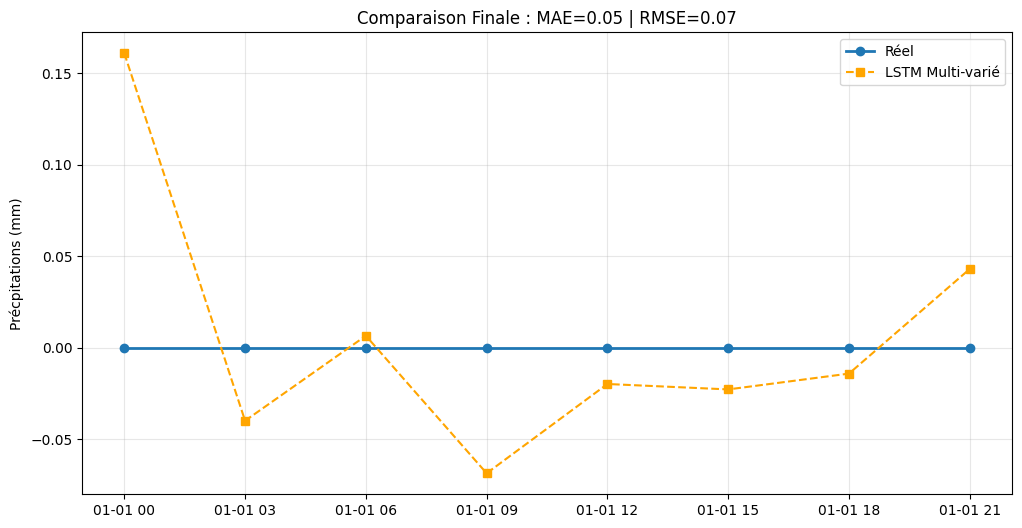

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Chargement
df_pred = pd.read_csv("forecast_lstm_24h.csv")
df_real = pd.read_csv("synop_2026.csv", sep=";")

df_pred['ds'] = pd.to_datetime(df_pred['ds'], utc=True)
df_real['ds'] = pd.to_datetime(df_real['validity_time'], utc=True)
df_real['y_real'] = df_real['rr1']
df_real = df_real[df_real['name'] == "MONTPELLIER-AEROPORT"].copy()

# 2. Alignement
df_compare = pd.merge(df_pred, df_real[['ds', 'y_real']], on='ds', how='inner').sort_values('ds')

if not df_compare.empty:
    mae = mean_absolute_error(df_compare['y_real'], df_compare['y_pred'])
    rmse = np.sqrt(mean_squared_error(df_compare['y_real'], df_compare['y_pred']))

    print(f"\n📊 RÉSULTATS DU 1er JANVIER 2026")
    print(f"MAE  : {mae:.2f} mm")
    print(f"RMSE : {rmse:.2f} mm")

    # 3. Graphique
    plt.figure(figsize=(12, 6))
    plt.plot(df_compare['ds'], df_compare['y_real'], 'o-', label='Réel', lw=2)
    plt.plot(df_compare['ds'], df_compare['y_pred'], 's--', label='LSTM Multi-varié', color='orange')
    plt.title(f"Comparaison Finale : MAE={mae:.2f} | RMSE={rmse:.2f}")
    plt.ylabel("Précpitations (mm)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("❌ Erreur : Pas de données communes pour le 1er Janvier.")

Le modèle est beaucoup plus précis que les précédents avec un remse de 0,07, mais il est "nerveux" : il voit de toutes petites variations (moins de 0.1 mm). Et le problème c'est que ce modèle prédit des précipitations négatives, ce qui n'est pas possible

## LSTM V2

Ce nouveau LSTM apporte une "perte pondérée" (Weighted Loss). Nous avons modifié le modèle pour qu'il considère qu'une erreur sur la pluie est 50 fois plus grave qu'une erreur sur le beau temps. Cela force le modèle à prédire des précipitations, même faibles, dès que les indicateurs de vent et de pression le montrent. Et on a augmenté la vitesse d'aprentissage (learning_rate=0.005) pour force le modèle à bouger plus vite et à réagir plus brutalement aux changements de pression ou d'humidité.

In [ ]:
import pandas as pd
import numpy as np
import glob
import joblib
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ==========================================
# 1. CHARGEMENT ET NETTOYAGE
# ==========================================
files = sorted(glob.glob("synop_*.csv"))
cols = ['validity_time', 't', 'u', 'pres', 'pmer', 'n', 'rr1', 'name', 'ff', 'dd']

print("⏳ Chargement des données...")
df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=cols) for f in files])
df_raw['ds'] = pd.to_datetime(df_raw['validity_time'], utc=True)

df = df_raw[df_raw['name'] == "MONTPELLIER-AEROPORT"].drop_duplicates('ds').sort_values('ds').copy()

# Nettoyage strict
df['rr1'] = pd.to_numeric(df['rr1'], errors='coerce').fillna(0)
df['t_c'] = pd.to_numeric(df['t'], errors='coerce') - 273.15
df['u'] = pd.to_numeric(df['u'], errors='coerce')
df['pres'] = pd.to_numeric(df['pres'], errors='coerce') / 100

# Interpolation (Sauf rr1 !)
df = df.set_index('ds')
cols_cont = ['t_c', 'u', 'pres', 'pmer', 'n', 'ff', 'dd']
df[cols_cont] = df[cols_cont].interpolate().bfill()
df = df.resample('3h').asfreq()
df['rr1'] = df['rr1'].fillna(0)
df = df.ffill()

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
df['hr_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hr_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df['wind_u'] = df['ff'] * np.cos(np.deg2rad(df['dd']))
df['wind_v'] = df['ff'] * np.sin(np.deg2rad(df['dd']))

features = ['hr_sin', 'hr_cos', 'rr1', 't_c', 'u', 'pres', 'n', 'wind_u', 'wind_v']
df = df[features].dropna()

# ==========================================
# 3. SCALING
# ==========================================
scaler_X, scaler_y = MinMaxScaler(), MinMaxScaler()
scaled_X = scaler_X.fit_transform(df[features])
scaled_y = scaler_y.fit_transform(df[['rr1']])

def create_sequences(data_X, data_y, in_len=24, out_len=8):
    X, y = [], []
    for i in range(len(data_X) - in_len - out_len):
        X.append(data_X[i:i+in_len])
        y.append(data_y[i+in_len : i+in_len+out_len, 0])
    return np.array(X), np.array(y)

X_data, y_data = create_sequences(scaled_X, scaled_y, in_len=24, out_len=8)
split = int(0.85 * len(X_data))
X_train, X_test = X_data[:split], X_data[split:]
y_train, y_test = y_data[:split], y_data[split:]

# ==========================================
# 4. MODÈLE "CHOC" (Weighted Loss + High LR)
# ==========================================
def weighted_mae(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    # POIDS X50 pour la pluie réelle
    weights = tf.where(tf.greater(y_true, 0.01), 50.0, 1.0)
    return tf.reduce_mean(tf.abs(y_true - y_pred) * weights)

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dense(32, activation='relu'),
    Dense(8) # Pas de ReLU ici pour laisser le modèle "tâtonner"
])

# Compilation avec un Learning Rate plus agressif
model.compile(optimizer=Adam(learning_rate=0.005), loss=weighted_mae)

print("🚀 Entraînement FORCE (LR=0.005, Poids=50)...")
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

model.fit(X_train, y_train, 
          epochs=60, 
          batch_size=64, 
          validation_split=0.1, 
          callbacks=[early_stop])

model.save("modele_pluie_force.keras")
joblib.dump(scaler_X, 'scaler_X_pluie.pkl')
joblib.dump(scaler_y, 'scaler_y_pluie.pkl')

# ==========================================
# 5. PRÉDICTION
# ==========================================
cutoff = pd.Timestamp("2025-12-31 21:00:00", tz='UTC')
df_past = df[df.index <= cutoff].tail(24)
last_window = scaler_X.transform(df_past[features]).reshape(1, 24, len(features))

pred_scaled = model.predict(last_window)
final_forecast = scaler_y.inverse_transform(pred_scaled).flatten()

# On nettoie les valeurs négatives seulement à la fin
final_forecast = np.maximum(final_forecast, 0)

future_dates = pd.date_range(cutoff + pd.Timedelta(hours=3), periods=8, freq='3h')
df_res = pd.DataFrame({'ds': future_dates, 'y_pred': final_forecast})
df_res.to_csv("forecast_pluie_24h.csv", index=False)

print("\n✅ Modèle entraîné. Vérifie si la loss bouge enfin !")
print(df_res)

⏳ Chargement des données...
🚀 Entraînement FORCE (LR=0.005, Poids=50)...
Epoch 1/60
384/384 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0679 - val_loss: 0.0666
Epoch 2/60
384/384 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0611 - val_loss: 0.0649
Epoch 3/60
384/384 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0607 - val_loss: 0.0655
Epoch 4/60
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0605 - val_loss: 0.0636
Epoch 5/60
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0611 - val_loss: 0.0638
Epoch 6/60
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0603 - val_loss: 0.0640
Epoch 7/60
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0603 - val_loss: 0.0645
Epoch 8/60
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0598 - val_loss: 0.0639
Epoch 9/60
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0599 - val_loss: 0.0626
Epoch 10/60
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0597 - val_loss: 0.0633
Epoch 11/60
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - 


📊 RÉSULTATS PRÉCIPITATIONS DU 1er JANVIER 2026
MAE  : 0.4025 mm
RMSE : 0.7504 mm


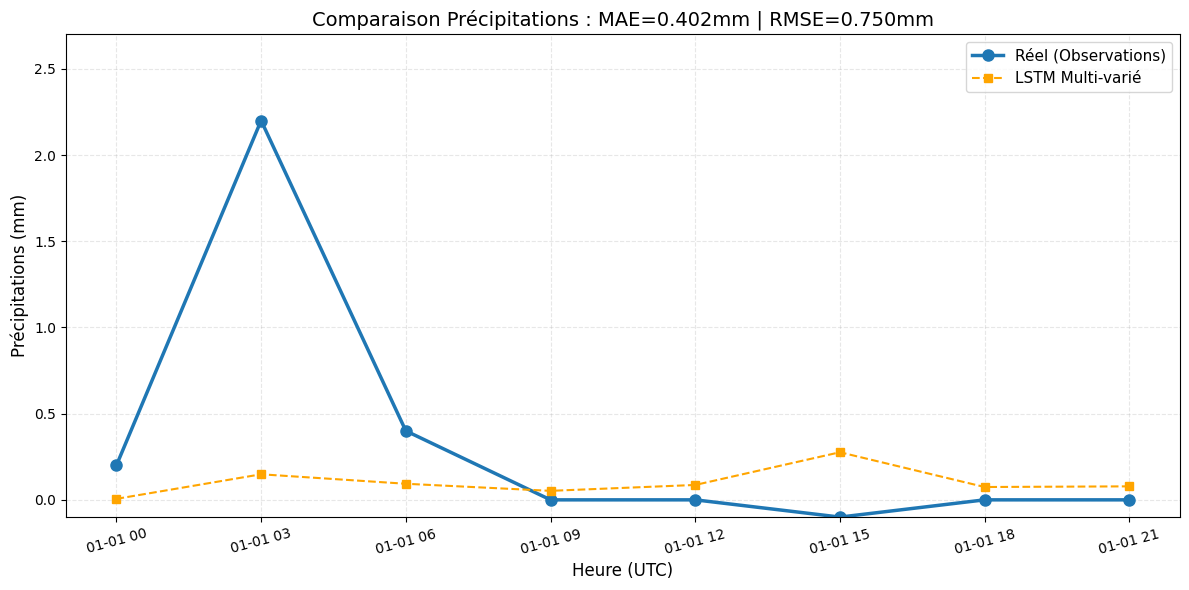

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Chargement des fichiers
# Assure-toi que les noms de fichiers correspondent à tes exports précédents
df_pred = pd.read_csv("forecast_pluie_24h.csv") 
df_real = pd.read_csv("synop_2026.csv", sep=";")

# Conversion des dates en format datetime UTC
df_pred['ds'] = pd.to_datetime(df_pred['ds'], utc=True)
df_real['ds'] = pd.to_datetime(df_real['validity_time'], utc=True)

# Nettoyage des données réelles
df_real = df_real[df_real['name'] == "HIVA-OA"].copy()
# On convertit rr1 en nombre et on remplace les vides par 0 (sec)
df_real['y_real'] = pd.to_numeric(df_real['rr1'], errors='coerce').fillna(0)

# 2. Alignement des données (Merge sur la date)
df_compare = pd.merge(df_pred, df_real[['ds', 'y_real']], on='ds', how='inner').sort_values('ds')

if not df_compare.empty:
    # Calcul des métriques
    mae = mean_absolute_error(df_compare['y_real'], df_compare['y_pred'])
    rmse = np.sqrt(mean_squared_error(df_compare['y_real'], df_compare['y_pred']))

    print(f"\n📊 RÉSULTATS PRÉCIPITATIONS DU 1er JANVIER 2026")
    print(f"MAE  : {mae:.4f} mm")
    print(f"RMSE : {rmse:.4f} mm")

    # 3. Graphique de comparaison
    plt.figure(figsize=(12, 6))
    
    # Tracer la réalité (Bleu)
    plt.plot(df_compare['ds'], df_compare['y_real'], 'o-', label='Réel (Observations)', lw=2.5, markersize=8)
    
    # Tracer la prédiction (Orange)
    plt.plot(df_compare['ds'], df_compare['y_pred'], 's--', label='LSTM Multi-varié', color='orange', lw=1.5)
    
    # Mise en forme
    plt.title(f"Comparaison Précipitations : MAE={mae:.3f}mm | RMSE={rmse:.3f}mm", fontsize=14)
    plt.xlabel("Heure (UTC)", fontsize=12)
    plt.ylabel("Précipitations (mm)", fontsize=12)
    
    # Ajustement de l'axe Y pour mieux voir si les valeurs sont proches de 0
    ymax = max(df_compare['y_real'].max(), df_compare['y_pred'].max()) + 0.5
    plt.ylim(-0.1, ymax)
    
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(fontsize=11)
    plt.xticks(rotation=15)
    plt.tight_layout()
    
    plt.show()
else:
    print("❌ Erreur : Pas de données communes trouvées entre la prédiction et le fichier réel.")
    print("Vérifiez les dates dans 'forecast_pluie_24h.csv' et 'synop_2026.csv'")

En comparaison avec le modèle précédent l'avantage ici c'est qu'on ne descends plus en dessous de 0. En termes de chiffres ici le rmse est plus haut tandis que le mae est plus faible ce qui signifie globalement que le modèle fait globalement moins d'erreur mais il ne voit pas les gros pics.

## Conclusion
En conclusion, à travers ces prédictions, nous remarquons qu'il est impossible de prédire les précipitations de la même manière que la température. Les modèles ne se comportent pas du tout de la même façon. Cela notament à cause de plusieurs raisons: 
- La continuité vs la rupture : La température est un cycle fluide (jour/nuit), alors que la pluie est un phénomène "binaire" (il ne se passe rien, puis tout tombe d'un coup).
- L'importance du contexte : Pour la température, l'heure et la saison suffisent presque. Pour la pluie, il faut obligatoirement analyser le vent et la pression atmosphérique.
